# 02. Líneas base (Fase 2)

**Objetivo:** definir contra qué vamos a comparar los modelos de la Fase 3. Una "línea
base" es el resultado que se obtiene con el método más simple posible, y si un modelo
más sofisticado no la supera con claridad, entonces no está aportando.

**Reglas metodológicas que sigue este notebook (y por qué):**

1. **El conjunto de prueba no se toca.** Aquí solo se usa `train.parquet`. El 20% de
   prueba quedó apartado en `src/split.py` y se reserva para la evaluación final del
   proyecto, así ninguna decisión se "contamina" con datos de prueba.
2. **Todo se evalúa con validación cruzada estratificada de 5 particiones.** Cada flujo
   lo predice un modelo que nunca lo vio, y la estratificación mantiene la proporción de
   cada clase en cada partición.
3. **El escalado (StandardScaler) va dentro del pipeline**, de modo que se ajusta solo
   con el tramo de entrenamiento de cada partición y nunca con los datos que se van a
   predecir.
4. **No usamos accuracy.** Con 83% de tráfico normal, decir "todo es normal" ya acierta
   el 83%, así que la exactitud global no dice nada útil. En su lugar usamos macro-F1
   (el promedio simple del F1 de cada clase, donde las clases raras pesan igual que las
   grandes), precisión y recall por clase, matriz de confusión y curva Precision-Recall.
5. **Todavía no hay remuestreo** (SMOTE y submuestreo quedan para la Fase 3), pero los
   pipelines ya son de `imblearn`. Así, en la Fase 3 el remuestreo se agrega como un paso
   más y se aplica únicamente al tramo de entrenamiento de cada partición, nunca al
   dataset completo.

**Modelos de esta fase:**
- `DummyClassifier (most_frequent)`: es el "piso", predice siempre la clase más
  frecuente sin mirar las features.
- Regresión logística estandarizada: el modelo interpretable más simple, en su versión
  binaria (Normal vs Ataque) y multiclase (tipo de tráfico).

In [1]:
import sys

sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

from src.config import ARCHIVO_TRAIN, COLUMNA_ETIQUETA, RANDOM_STATE, RUTA_FIGURAS
from src.etiquetas import (
    CLASES_EXCLUIDAS_MULTICLASE,
    etiqueta_binaria,
    etiqueta_multiclase,
    mascara_multiclase,
)
from src.features import features_finales

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Solo se usa el conjunto de entrenamiento; el test quedó apartado en src/split.py y no se toca.
train = pd.read_parquet(ARCHIVO_TRAIN)
FEATURES = features_finales(train)
X = train[FEATURES].astype(np.float32).values
y_bin = etiqueta_binaria(train[COLUMNA_ETIQUETA]).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Entrenamiento: {X.shape[0]:,} flujos, {X.shape[1]} features")
print(f"Vista binaria: {int(y_bin.sum()):,} ataques ({100 * y_bin.mean():.1f}%)")

Entrenamiento: 1,998,462 flujos, 48 features
Vista binaria: 340,593 ataques (17.0%)


In [2]:
def tabla_metricas(y_true, y_pred):
    """Precisión, recall y F1 por clase. La fila de accuracy se quita a
    propósito (regla 4: con este desbalance no dice nada útil)."""
    reporte = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    reporte.pop("accuracy", None)
    tabla = pd.DataFrame(reporte).T.rename(
        columns={"precision": "precisión", "f1-score": "F1", "support": "soporte"}
    )
    tabla["soporte"] = tabla["soporte"].astype(int)
    promedios = tabla.loc[["macro avg", "weighted avg"]]
    clases = tabla.drop(index=["macro avg", "weighted avg"]).sort_values(
        "soporte", ascending=False
    )
    return pd.concat([clases, promedios]).round(3)

## 1. Línea base binaria: Normal vs Ataque

### 1.1 El piso: predecir siempre "Normal"

In [3]:
piso_bin = DummyClassifier(strategy="most_frequent")
pred_piso_bin = cross_val_predict(piso_bin, X, y_bin, cv=cv, n_jobs=5)
tabla_metricas(
    np.where(y_bin == 1, "Ataque", "Normal"),
    np.where(pred_piso_bin == 1, "Ataque", "Normal"),
)

,precisión,recall,F1,soporte
Normal,0.830,1.00,0.907,1657869
Ataque,0.000,0.00,0.000,340593
macro avg,0.415,0.50,0.453,1998462
weighted avg,0.688,0.83,0.752,1998462


El piso "acierta" el 83% de las filas sin detectar **ni un solo ataque** (recall de
Ataque = 0). Este es el mejor ejemplo de por qué no usamos accuracy en este proyecto.
El macro-F1 del piso (~0,45) es la cifra que hay que superar.

### 1.2 Regresión logística binaria

In [4]:
pipe_bin = Pipeline(
    [
        ("escalado", StandardScaler()),
        # En la Fase 3 el remuestreo (SMOTE o submuestreo) se agrega aquí como un
        # paso intermedio, e imblearn lo aplica solo al tramo de entrenamiento de cada partición.
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
proba_bin = cross_val_predict(
    pipe_bin, X, y_bin, cv=cv, method="predict_proba", n_jobs=5
)[:, 1]
pred_bin = (proba_bin >= 0.5).astype("int8")
tabla_metricas(
    np.where(y_bin == 1, "Ataque", "Normal"),
    np.where(pred_bin == 1, "Ataque", "Normal"),
)

,precisión,recall,F1,soporte
Normal,0.971,0.976,0.973,1657869
Ataque,0.879,0.857,0.868,340593
macro avg,0.925,0.917,0.921,1998462
weighted avg,0.955,0.956,0.955,1998462


In [5]:
matriz_bin = confusion_matrix(y_bin, pred_bin)
pd.DataFrame(
    matriz_bin,
    index=["real: Normal", "real: Ataque"],
    columns=["predicho: Normal", "predicho: Ataque"],
)

,predicho: Normal,predicho: Ataque
real: Normal,1617515,40354
real: Ataque,48536,292057


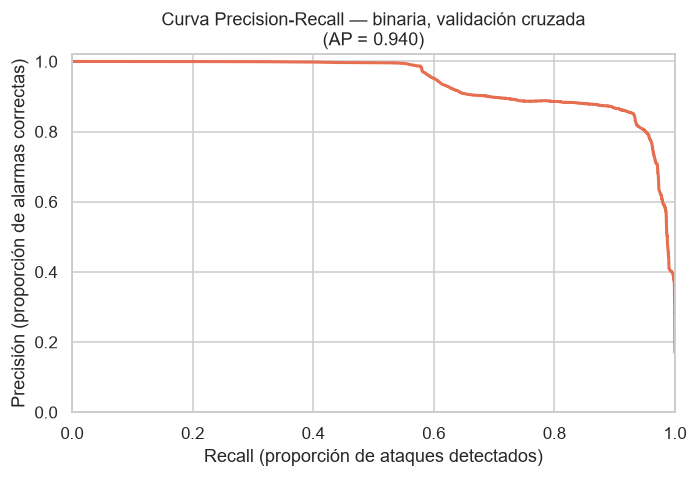

In [6]:
precision_b, recall_b, _ = precision_recall_curve(y_bin, proba_bin)
ap_bin = average_precision_score(y_bin, proba_bin)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(recall_b, precision_b, color="#e76f51", lw=2)
ax.set_xlabel("Recall (proporción de ataques detectados)")
ax.set_ylabel("Precisión (proporción de alarmas correctas)")
ax.set_title(f"Curva Precision-Recall — binaria, validación cruzada\n(AP = {ap_bin:.3f})")
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "04_pr_binaria.png", bbox_inches="tight")
plt.show()

**Lectura.** La curva muestra el intercambio entre detectar más ataques (recall) y
equivocarse menos al dar la alarma (precisión) a medida que se mueve el umbral de
decisión. Con el umbral por defecto (0,5) ya tenemos una línea base fuerte, y la curva
sirve para que en la Fase 3 se compare el intercambio completo en lugar de un solo punto.

## 2. Línea base multiclase: ¿qué tipo de tráfico es?

Como se documenta en `src/etiquetas.py`, los 3 ataques web se agrupan en la familia
**"Web Attack"**, y **Heartbleed** (9 casos en train) e **Infiltration** (29) quedan
fuera del multiclase, porque sus métricas por clase serían ruido con ~2-6 casos por
partición. Las dos clases se siguen contando en la vista binaria.

In [7]:
mascara = mascara_multiclase(train[COLUMNA_ETIQUETA]).values
X_multi = X[mascara]
y_multi = etiqueta_multiclase(train.loc[mascara, COLUMNA_ETIQUETA]).astype(str).values

print(f"Filas multiclase: {len(y_multi):,} "
      f"(excluidas {int((~mascara).sum())} filas de {CLASES_EXCLUIDAS_MULTICLASE})")
print(f"Clases ({len(np.unique(y_multi))}):")
print(pd.Series(y_multi).value_counts().to_string())

Filas multiclase: 1,998,424 (excluidas 38 filas de ['Heartbleed', 'Infiltration'])


Clases (11):
BENIGN              1657869
DoS Hulk             138277
DDoS                 102411
PortScan              72555
DoS GoldenEye          8229
FTP-Patator            4745
DoS slowloris          4308
DoS Slowhttptest       4182
SSH-Patator            2575
Web Attack             1715
Bot                    1558


### 2.1 El piso multiclase

In [8]:
piso_multi = DummyClassifier(strategy="most_frequent")
pred_piso_multi = cross_val_predict(piso_multi, X_multi, y_multi, cv=cv, n_jobs=5)
f1_piso_multi = f1_score(y_multi, pred_piso_multi, average="macro")
print(f"macro-F1 del piso (predice siempre BENIGN): {f1_piso_multi:.3f}")

macro-F1 del piso (predice siempre BENIGN): 0.082


### 2.2 Regresión logística multiclase

In [9]:
pipe_multi = Pipeline(
    [
        ("escalado", StandardScaler()),
        # En la Fase 3 el remuestreo se agrega aquí (ver la nota del modelo binario).
        ("modelo", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)
proba_multi = cross_val_predict(
    pipe_multi, X_multi, y_multi, cv=cv, method="predict_proba", n_jobs=5
)
clases_modelo = np.unique(y_multi)  # predict_proba ordena sus columnas en este mismo orden
pred_multi = clases_modelo[np.argmax(proba_multi, axis=1)]
tabla_metricas(y_multi, pred_multi)

,precisión,recall,F1,soporte
BENIGN,0.989,0.982,0.986,1657869
DoS Hulk,0.996,0.943,0.969,138277
DDoS,0.996,0.981,0.989,102411
PortScan,0.721,0.993,0.835,72555
DoS GoldenEye,0.937,0.801,0.864,8229
FTP-Patator,0.967,0.987,0.977,4745
DoS slowloris,0.958,0.885,0.920,4308
DoS Slowhttptest,0.819,0.796,0.807,4182
SSH-Patator,0.847,0.208,0.334,2575
Web Attack,0.250,0.003,0.007,1715


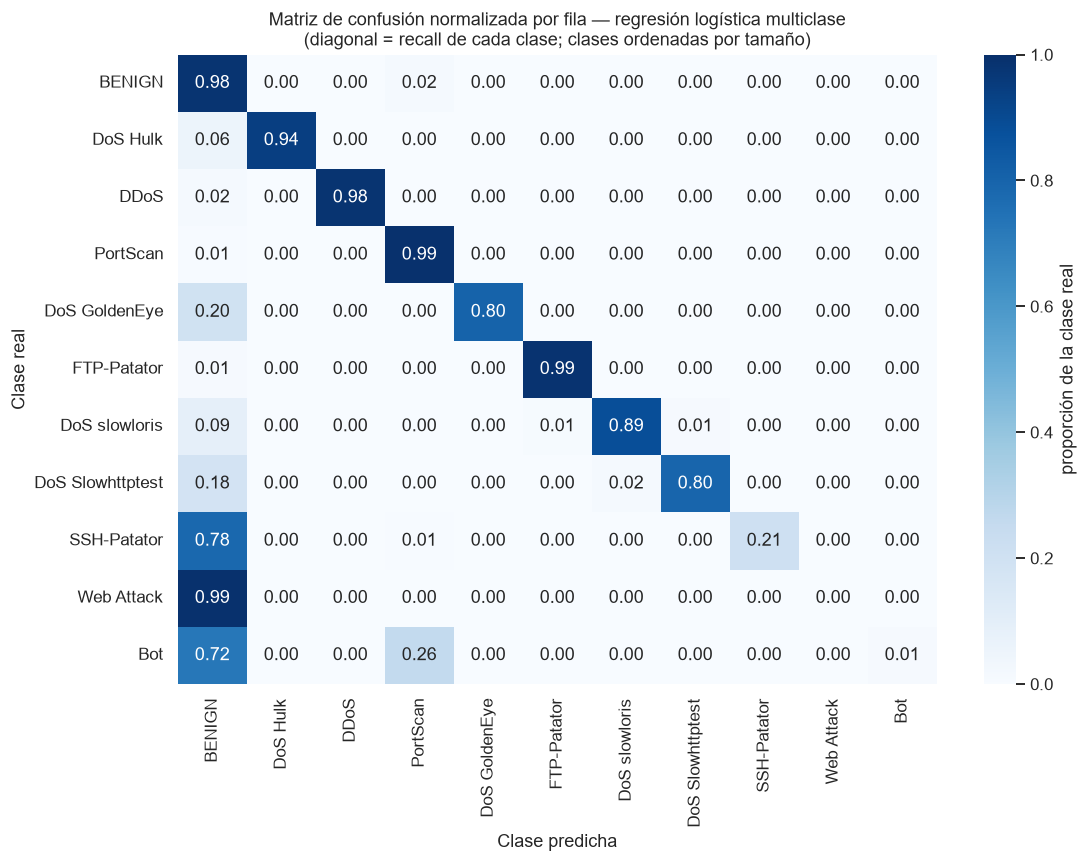

In [10]:
orden = pd.Series(y_multi).value_counts().index.tolist()
matriz = confusion_matrix(y_multi, pred_multi, labels=orden, normalize="true")

fig, ax = plt.subplots(figsize=(10.5, 8))
sns.heatmap(
    pd.DataFrame(matriz, index=orden, columns=orden),
    annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    cbar_kws={"label": "proporción de la clase real"}, ax=ax,
)
ax.set_ylabel("Clase real")
ax.set_xlabel("Clase predicha")
ax.set_title(
    "Matriz de confusión normalizada por fila — regresión logística multiclase\n"
    "(diagonal = recall de cada clase; clases ordenadas por tamaño)"
)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "05_matriz_confusion_multiclase.png", bbox_inches="tight")
plt.show()

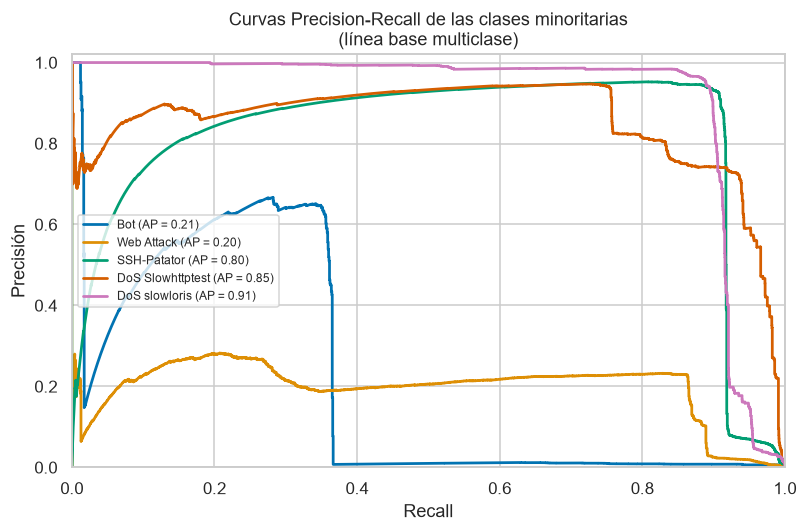

In [11]:
# Curvas Precision-Recall de las clases minoritarias (cada clase contra el resto)
minoritarias = ["Bot", "Web Attack", "SSH-Patator", "DoS Slowhttptest", "DoS slowloris"]

fig, ax = plt.subplots(figsize=(7.5, 5))
for clase in minoritarias:
    idx = list(clases_modelo).index(clase)
    y_una = (y_multi == clase).astype(int)
    prec, rec, _ = precision_recall_curve(y_una, proba_multi[:, idx])
    ap = average_precision_score(y_una, proba_multi[:, idx])
    ax.plot(rec, prec, lw=1.8, label=f"{clase} (AP = {ap:.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisión")
ax.set_title("Curvas Precision-Recall de las clases minoritarias\n(línea base multiclase)")
ax.legend(fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "06_pr_minoritarias.png", bbox_inches="tight")
plt.show()

## 3. Resumen: las cifras que hay que superar en la Fase 3

In [12]:
resumen = pd.DataFrame(
    {
        "macro-F1 (validación cruzada)": [
            f1_score(y_bin, pred_piso_bin, average="macro"),
            f1_score(y_bin, pred_bin, average="macro"),
            f1_piso_multi,
            f1_score(y_multi, pred_multi, average="macro"),
        ]
    },
    index=[
        "Binaria — piso (siempre 'Normal')",
        "Binaria — regresión logística",
        "Multiclase — piso (siempre 'BENIGN')",
        "Multiclase — regresión logística",
    ],
).round(3)
resumen

,macro-F1 (validación cruzada)
Binaria — piso (siempre 'Normal'),0.453
Binaria — regresión logística,0.921
Multiclase — piso (siempre 'BENIGN'),0.082
Multiclase — regresión logística,0.701


**Conclusiones de la fase de líneas base.**

- El piso confirma que la accuracy no sirve en este problema: acierta el 83% de las
  filas con recall 0 en todos los ataques.
- La regresión logística binaria ya es una línea base exigente. El reto real está en el
  multiclase, donde las clases minoritarias (visibles en la matriz de confusión y en las
  curvas PR) son las que bajan el macro-F1.
- **Para la Fase 3:** cualquier técnica de desbalance (pesos de clase, SMOTE,
  submuestreo) tiene que mejorar el macro-F1 multiclase y el recall de las clases
  minoritarias frente a estas cifras, usando la misma división de datos, el mismo esquema
  de validación cruzada y el mismo conjunto de features. El conjunto de prueba sigue sin
  tocarse.